In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Try reading the CSV file and check the columns
df = pd.read_csv('data/temp/chats_edu.csv', encoding='utf-8', sep=',')

# Filter out sessions with less than 2 messages
df = df[df.groupby('session_id')['student_query'].transform('size') > 1]

# Count the number of sessions
session_count = df['session_id'].nunique()
print(f"Number chats: {session_count}")

# Average messages per session
avg_messages_per_session = df.groupby('session_id').size().mean()
print(f"Average messages per session: {avg_messages_per_session:.2f}\n\n")


df['delta_gt_30'] = df['delta'].apply(lambda x: 1 if x > 30 else 0)
df['delta_gt_45'] = df['delta'].apply(lambda x: 1 if x > 45 else 0)
df['delta_gt_60'] = df['delta'].apply(lambda x: 1 if x > 60 else 0)


df_filtered = df[['session_id', 'delta', 'delta_gt_30', 'delta_gt_45', 'delta_gt_60']]

# Group by 'session_id' and sum the delta delta_gt_30
grouped = df_filtered.groupby('session_id').sum().reset_index()
# Adds a new column to count the number of messages per session
message_counts = df.groupby('session_id').size().reset_index(name='message_count')
grouped = grouped.merge(message_counts, on='session_id', how='left')

# Verifique se um session_id tem mais de uma sub seção
grouped['chats_30'] = grouped['delta_gt_30'] + 1
grouped['chats_45'] = grouped['delta_gt_45'] + 1
grouped['chats_60'] = grouped['delta_gt_60'] + 1

session_count_30 = grouped['chats_30'].sum()
print(f"Number of study chat with spacing > 30: {session_count_30}")
session_count_45 = grouped['chats_45'].sum()
print(f"Number of study chat with spacing > 45: {session_count_45}")
session_count_60 = grouped['chats_60'].sum()
print(f"Number of study chat with spacing > 60: {session_count_60}\n\n")

grouped['agv_30'] = grouped['message_count'] / grouped['chats_30']
grouped['agv_45'] = grouped['message_count'] / grouped['chats_45']
grouped['agv_60'] = grouped['message_count'] / grouped['chats_60']

agv_30 = grouped['agv_30'].mean()
agv_45 = grouped['agv_45'].mean()
agv_60 = grouped['agv_60'].mean()
print(f"Average messages per session with spacing > 30: {agv_30}")
print(f"Average messages per session with spacing > 45: {agv_45}")
print(f"Average messages per session with spacing > 60: {agv_60}\n\n")


# save the grouped DataFrame to a CSV file
grouped.to_csv('data/temp/chats_edu_grouped.csv', index=False, encoding='utf-8-sig')

grouped.head(10)








Number chats: 1044
Average messages per session: 3.38


Number of study chat with spacing > 30: 1242
Number of study chat with spacing > 45: 1164
Number of study chat with spacing > 60: 1124


Average messages per session with spacing > 30: 2.930890804597701
Average messages per session with spacing > 45: 3.087611749680715
Average messages per session with spacing > 60: 3.173499361430396




,session_id,delta,delta_gt_30,delta_gt_45,delta_gt_60,message_count,chats_30,chats_45,chats_60,agv_30,agv_45,agv_60
0,00019af4-d13d-43be-90aa-981a07434719,72.78,1,1,0,3,2,2,1,1.5,1.5,3.0
1,00a7e28f-f085-4648-be99-ccd67dd29404,3.19,0,0,0,3,1,1,1,3.0,3.0,3.0
2,00e746b4-955b-43ef-bf46-cac0df7cd294,30.93,1,0,0,2,2,1,1,1.0,2.0,2.0
3,013fef1e-eb76-4868-b159-4bcfadd401fa,0.62,0,0,0,2,1,1,1,2.0,2.0,2.0
4,0165a76d-89c8-43a7-8560-b4eacfbdfa22,0.67,0,0,0,2,1,1,1,2.0,2.0,2.0
5,0183c26a-61d1-4894-baca-fcf7d2d003ed,9.76,0,0,0,3,1,1,1,3.0,3.0,3.0
6,018ed39c-1e44-493d-8afd-fc08638a6540,0.52,0,0,0,2,1,1,1,2.0,2.0,2.0
7,0195650c-d82f-40c3-8215-0d24d7e29034,0.95,0,0,0,2,1,1,1,2.0,2.0,2.0
8,01c97618-de92-4996-bfab-ea24052000ee,26.19,0,0,0,4,1,1,1,4.0,4.0,4.0
9,01d478cd-dd09-4e55-b25e-ac8997b1da2b,0.70,0,0,0,2,1,1,1,2.0,2.0,2.0


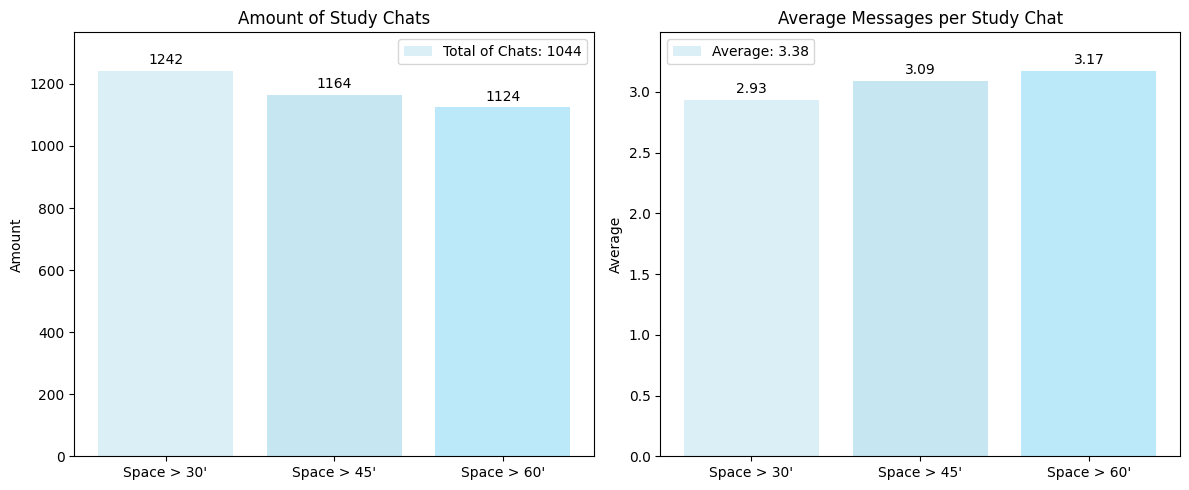

In [11]:
import numpy as np

# Dados para o gráfico
labels_totais = ['Space > 30\'', 'Space > 45\'', 'Space > 60\'']
valores_totais = [session_count_30, session_count_45, session_count_60]

labels_medias = ['Space > 30\'', 'Space > 45\'', 'Space > 60\'']
valores_medias = [agv_30, agv_45, agv_60]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de totais (sem o total de sessões como barra)
bars1 = axs[0].bar(labels_totais, valores_totais, color=["#DBEFF6", "#C6E6F2", "#BCE9FA"])
axs[0].set_title('Amount of Study Chats')
axs[0].set_ylabel('Amount')
axs[0].set_ylim(0, max(valores_totais) * 1.1)
for i, v in enumerate(valores_totais):
    axs[0].text(i, v + max(valores_totais)*0.01, str(int(v)), ha='center', va='bottom')
axs[0].legend([f"Total of Chats: {session_count}"])

# Gráfico de médias (sem a média geral como barra)
bars2 = axs[1].bar(labels_medias, valores_medias, color=["#DBEFF6", "#C6E6F2", "#BCE9FA"])
axs[1].set_title('Average Messages per Study Chat')
axs[1].set_ylabel('Average')
axs[1].set_ylim(0, max(valores_medias) * 1.1)
for i, v in enumerate(valores_medias):
    axs[1].text(i, v + max(valores_medias)*0.01, f'{v:.2f}', ha='center', va='bottom')
axs[1].legend([f"Average: {avg_messages_per_session:.2f}"])

plt.tight_layout()
plt.show()

In [12]:
print(f"Increase with space 30: {session_count_30 - session_count}")
print(f"Percentage: {(session_count_30 * 100 / session_count) - 100:.2f}%")

print(f"Increase with space 45: {session_count_45 - session_count}")
print(f"Percentage: {(session_count_45 * 100 / session_count) - 100:.2f}%")

print(f"Increase with space 60: {session_count_60 - session_count}")
print(f"Percentage: {(session_count_60 * 100 / session_count) - 100:.2f}%")

print(f"\n\nDecrease with space 30 average: {agv_30 - avg_messages_per_session:.2f}")
print(f"Percentage: {((agv_30 - avg_messages_per_session) * 100 / avg_messages_per_session):.2f}%")

print(f"Decrease with space 45 average: {agv_45 - avg_messages_per_session:.2f}")
print(f"Percentage: {((agv_45 - avg_messages_per_session) * 100 / avg_messages_per_session):.2f}%")

print(f"Decrease with space 60 average: {agv_60 - avg_messages_per_session:.2f}")
print(f"Percentage: {((agv_60 - avg_messages_per_session) * 100 / avg_messages_per_session):.2f}%")






Increase with space 30: 198
Percentage: 18.97%
Increase with space 45: 120
Percentage: 11.49%
Increase with space 60: 80
Percentage: 7.66%


Decrease with space 30 average: -0.45
Percentage: -13.20%
Decrease with space 45 average: -0.29
Percentage: -8.55%
Decrease with space 60 average: -0.20
Percentage: -6.01%
